## Setup

First we load shared notebook helpers, environment variables, the model name, and the test prompt that we will reuse across all agent configurations. Keeping the user request fixed is important: it lets us compare interface choices rather than accidentally comparing different tasks.

In [16]:
import sys
from pathlib import Path
from dotenv import load_dotenv
from pathlib import Path
import os

experiments_root = str(Path("..").resolve())
if experiments_root not in sys.path:
    sys.path.append(experiments_root)

dotenv_path = Path(".env").resolve()
if load_dotenv(dotenv_path=dotenv_path, override=True):
    print(f"Environment loaded from: {dotenv_path}")
else:
    print(f"No .env file found at: {dotenv_path}; relying on existing environment")

for env_var in ("OPENAI_API_KEY", "LANGCHAIN_TRACING_V2", "LANGCHAIN_API_KEY", "LANGCHAIN_PROJECT", "GITHUB_PERSONAL_ACCESS_TOKEN"):
    status = "SET" if os.getenv(env_var) else "NOT SET"
    print(f"{env_var}: {status}")

token = os.getenv("GITHUB_PERSONAL_ACCESS_TOKEN", "")
if token:
    print(f"GITHUB_PERSONAL_ACCESS_TOKEN suffix: {token[-4:]}")

Environment loaded from: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-lab/experiments/03-mcp-as-code/.env
OPENAI_API_KEY: SET
LANGCHAIN_TRACING_V2: SET
LANGCHAIN_API_KEY: SET
LANGCHAIN_PROJECT: NOT SET
GITHUB_PERSONAL_ACCESS_TOKEN: SET
GITHUB_PERSONAL_ACCESS_TOKEN suffix: ur3k


In [ ]:
from textwrap import dedent


model = "gpt-5-mini"

SYSTEM_PROMPT = dedent("""
    You are a coding assistant.
    Help the user implement code changes safely and clearly.
    When needed, use available tools to inspect files, run commands, and verify results.
    Before making changes, briefly state what you will do.
    After changes, summarize what was changed and why.
""") 
                       
TEST_PROMPT = dedent("""
    Use my authenticated GitHub account, check my 3 most recently updated repositories, 
    read each README, and tell me what I'm focusing on lately.
    Your response should be a maximum of one paragraph.
""")

## 1. MCP Path

We start from the original assumption many teams made: if an agent needs to work with GitHub, the answer is to expose GitHub through MCP tools. In that framing, MCP is not an alternative to shell discovery. It is the primary integration path people reached for.

This section establishes that baseline. Later sections test the newer idea that the alternative was often already there: a mature CLI that agents may be able to use directly, especially once we give them better operational guidance.

In [18]:
from mcp_helpers import load_mcp_servers, redact_mcp_servers

mcp_servers = load_mcp_servers("./mcp_config.json")
redact_mcp_servers(mcp_servers)

{'github-mcp-server': {'url': 'https://api.githubcopilot.com/mcp/',
  'headers': {'Authorization': 'Bearer ghp_...ur3k'},
  'transport': 'streamable_http'}}

In [19]:
from langchain_mcp_adapters.client import MultiServerMCPClient
client = MultiServerMCPClient(mcp_servers)
mcp_tools = await client.get_tools()

In [20]:
from mcp_helpers import print_tool_names_grid

print_tool_names_grid(mcp_tools, cols=3, col_width=40)

Total MCP tools: 44
add_comment_to_pending_review           add_issue_comment                       add_reply_to_pull_request_comment       
assign_copilot_to_issue                 create_branch                           create_or_update_file                   
create_pull_request                     create_pull_request_with_copilot        create_repository                       
delete_file                             fork_repository                         get_commit                              
get_copilot_job_status                  get_file_contents                       get_label                               
get_latest_release                      get_me                                  get_release_by_tag                      
get_tag                                 get_team_members                        get_teams                               
issue_read                              issue_write                             list_branches                           
list_commits

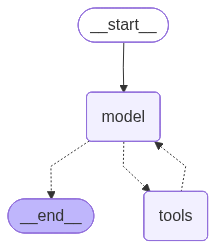

In [21]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from textwrap import dedent
from IPython.display import Image, display

mcp_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    tools=mcp_tools,
)

display(Image(mcp_agent.get_graph(xray=True).draw_mermaid_png()))

In [22]:
messages = await mcp_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================


Use my authenticated GitHub account, check my 3 most recently updated repositories, 
read each README, and tell me what I'm focusing on lately.
Your response should be a maximum of one paragraph.

================================== Ai Message ==================================

I'll (1) get your GitHub username from the authenticated account, (2) find your 3 most recently updated repositories, and (3) fetch each repo's README file and summarize what you've been focusing on lately in one paragraph. I'll start by getting your user info.
Tool Calls:
  get_me (call_i02yUQdMSBo862LnVTOHgdmH)
 Call ID: call_i02yUQdMSBo862LnVTOHgdmH
  Args:
================================= Tool Message =================================
Name: get_me

[{'type': 'text', 'text': '{"login":"esurovtsev","id":2109127,"profile_url":"https://github.com/esurovtsev","avatar_url":"https://avatars.githubusercontent.com/u/2109127?v=4","deta

In [ ]:
## 2. MCP as Code

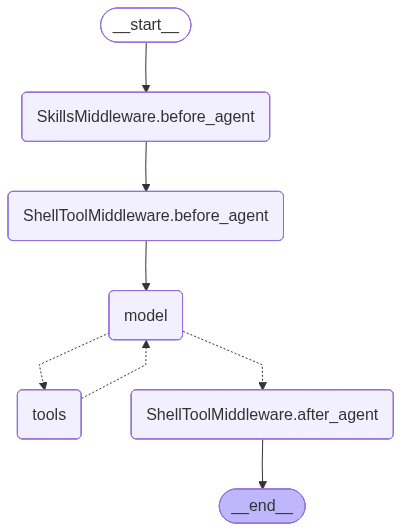

In [40]:
import os
from pathlib import Path
from langchain.agents.middleware import ShellToolMiddleware, HostExecutionPolicy
from deepagents.middleware import SkillsMiddleware
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends.filesystem import FilesystemBackend
from textwrap import dedent
from IPython.display import Image, display

skills_backend = FilesystemBackend(
    root_dir=Path(".").resolve(),
    virtual_mode=False,
)

shell_skill_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    middleware=[
        SkillsMiddleware(
            backend=skills_backend,
            sources=["skills"],
        ),
        FilesystemMiddleware(backend=skills_backend),
        ShellToolMiddleware(
            execution_policy=HostExecutionPolicy(),
            env={**os.environ},
        ),
    ],
)

display(Image(shell_skill_agent.get_graph(xray=True).draw_mermaid_png()))

In [41]:
messages = await shell_skill_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================


Use my authenticated GitHub account, check my 3 most recently updated repositories, 
read each README, and tell me what I'm focusing on lately.
Your response should be a maximum of one paragraph.

================================== Ai Message ==================================

Plan:
1) Open the mcp-scripting skill docs to see how to access your authenticated GitHub via the provided wrappers and which Python to use
2) Locate the helper scripts in the skill folder
3) Run a short Python snippet with the skill’s venv to list your 3 most recently updated repos and fetch each README
4) Summarize what you’ve been focusing on in one concise paragraph

Proceeding to read the skill instructions and discover scripts.
Tool Calls:
  ls (call_4ct0yHJwQeOyHyTqEodVDMoQ)
 Call ID: call_4ct0yHJwQeOyHyTqEodVDMoQ
  Args:
    path: /Users/esurovtsev/Projects/learning/LangChain Guides/langchain-lab/experiments/03-mcp-as-code